In [ ]:
# Task 4: Error Types — Programmatic
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd


Harmonic Series Terms


,Term,Exact Value,Rounded Value (3 d.p.)
0,1/1,1.000000,1.000
1,1/2,0.500000,0.500
2,1/3,0.333333,0.333
3,1/4,0.250000,0.250
4,1/5,0.200000,0.200
5,1/6,0.166667,0.167
6,1/7,0.142857,0.143
7,1/8,0.125000,0.125
8,1/9,0.111111,0.111
9,1/10,0.100000,0.100



Method 1 (Round each term first): 2.9290000000000003
Method 2 (Round final result only): 2.929
True Sum: 2.9289682539682538
Round-off Error: 3.1746031746493486e-05


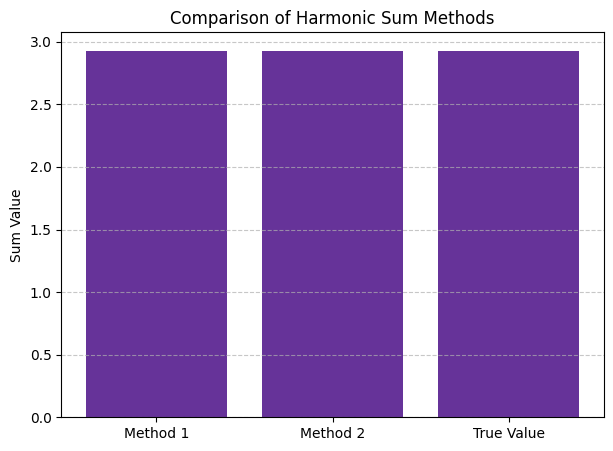

In [ ]:
# A. Round-off Error
# Harmonic Sum: S = 1 + 1/2 + 1/3 + ... + 1/10


# Generate harmonic terms
terms = [1/i for i in range(1, 11)]

# Method 1:
# Round each term to 3 decimal places BEFORE summation
rounded_terms = [round(term, 3) for term in terms]
method1_sum = sum(rounded_terms)

# Method 2:
# Sum exactly, THEN round the final result
exact_sum = sum(terms)
method2_sum = round(exact_sum, 3)

# True machine-precision value
true_sum = exact_sum

# Errors
roundoff_error = abs(method1_sum - true_sum)

# results
roundoff_df = pd.DataFrame({
    'Term': [f'1/{i}' for i in range(1, 11)],
    'Exact Value': terms,
    'Rounded Value (3 d.p.)': rounded_terms
})
print("\nHarmonic Series Terms")
display(roundoff_df)

print("\nMethod 1 (Round each term first):", method1_sum)
print("Method 2 (Round final result only):", method2_sum)
print("True Sum:", true_sum)
print("Round-off Error:", roundoff_error)

# Visualization
methods = ['Method 1', 'Method 2', 'True Value']
values = [method1_sum, method2_sum, true_sum]
plt.figure(figsize=(7, 5))
plt.bar(methods, values, color='rebeccapurple')
plt.ylabel('Sum Value')
plt.title('Comparison of Harmonic Sum Methods')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Taylor Series Approximations for e^0.5


,n,Approximation,True Value,Truncation Error
0,1,1.000000,1.648721,6.487213e-01
1,2,1.500000,1.648721,1.487213e-01
2,3,1.625000,1.648721,2.372127e-02
3,4,1.645833,1.648721,2.887937e-03
4,5,1.648438,1.648721,2.837707e-04
5,6,1.648698,1.648721,2.335403e-05
6,7,1.648720,1.648721,1.652645e-06
7,8,1.648721,1.648721,1.025454e-07
8,9,1.648721,1.648721,5.664166e-09
9,10,1.648721,1.648721,2.818772e-10



Using n = 3 terms
Approximation: 1.625
Truncation Error: 0.023721270700128194

Using n = 5 terms
Approximation: 1.6484375
Truncation Error: 0.00028377070012819416


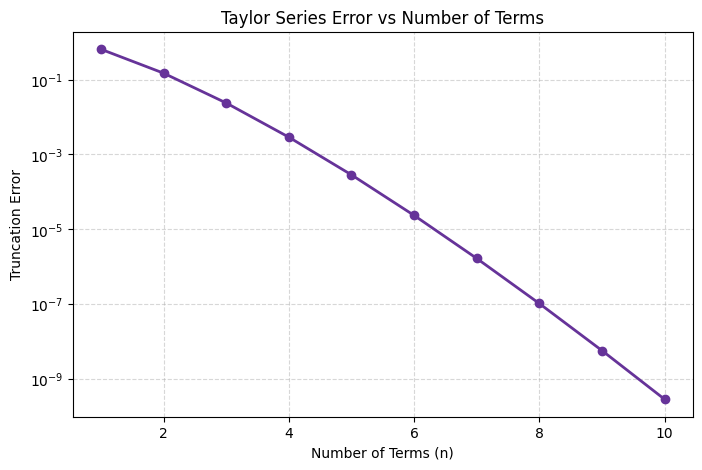

In [ ]:
# B. Truncation Error
# Taylor Series Approximation of e^0.5
x = 0.5
true_value = math.exp(x)
# Taylor Series Function
# Uses n terms
def taylor_exp(x, n):
    approximation = 0
    for k in range(n):
        approximation += (x**k) / math.factorial(k)
    return approximation

# Compute approximations and errors
n_values = list(range(1, 11))
approximations = []
errors = []

for n in n_values:
    approx = taylor_exp(x, n)
    error = abs(true_value - approx)

    approximations.append(approx)
    errors.append(error)
    #table
truncation_df = pd.DataFrame({
    'n': n_values,
    'Approximation': approximations,
    'True Value': [true_value]*len(n_values),
    'Truncation Error': errors
})

print("\nTaylor Series Approximations for e^0.5")
display(truncation_df)

approx_n3 = taylor_exp(x, 3)
approx_n5 = taylor_exp(x, 5)

error_n3 = abs(true_value - approx_n3)
error_n5 = abs(true_value - approx_n5)

print("\nUsing n = 3 terms")
print("Approximation:", approx_n3)
print("Truncation Error:", error_n3)

print("\nUsing n = 5 terms")
print("Approximation:", approx_n5)
print("Truncation Error:", error_n5)

# Plot Error vs n
plt.figure(figsize=(8,5))
plt.plot(n_values, errors, marker='o', color='rebeccapurple', linestyle='-', linewidth=2)
plt.xlabel('Number of Terms (n)')
plt.ylabel('Truncation Error')
plt.title('Taylor Series Error vs Number of Terms')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()

Nominal x: 0.5
Nominal y: 2.25

First-Order Propagation Method
dy/dx: 3.0
Estimated Error: 0.06
y ≈ 2.25 ± 0.06

Endpoint Method
g(0.48) = 2.1904
g(0.52) = 2.3104
Range: [2.1904, 2.3104]
Endpoint Error: 0.06040000000000001


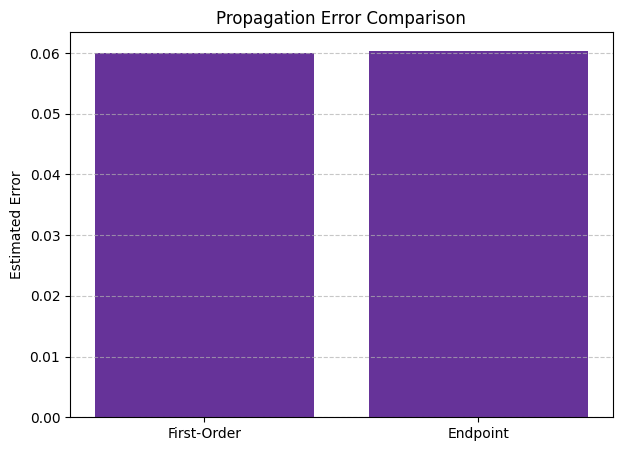

In [ ]:
# C. Propagation Error
# g(x) = (x + 1)^2
# x = 0.50 ± 0.02


# Given values
x = 0.50
delta_x = 0.02
# Function
def g(x):
    return (x + 1)**2

# Derivative

def dg_dx(x):
    return 2 * (x + 1)

# Nominal value
nominal_y = g(x)

# First-order propagation
first_order_error = abs(dg_dx(x)) * delta_x

# Endpoint method
x_low = x - delta_x
x_high = x + delta_x

y_low = g(x_low)
y_high = g(x_high)

endpoint_error = abs(y_high - nominal_y)
# Display results
print("Nominal x:", x)
print("Nominal y:", nominal_y)

print("\nFirst-Order Propagation Method")
print("dy/dx:", dg_dx(x))
print("Estimated Error:", first_order_error)
print(f"y ≈ {nominal_y} ± {first_order_error}")

print("\nEndpoint Method")
print("g(0.48) =", y_low)
print("g(0.52) =", y_high)
print(f"Range: [{y_low}, {y_high}]")
print("Endpoint Error:", endpoint_error)

# Visualization
methods = ['First-Order', 'Endpoint']
values = [first_order_error, endpoint_error]

plt.figure(figsize=(7,5))
plt.bar(methods, values, color='rebeccapurple')
plt.ylabel('Estimated Error')
plt.title('Propagation Error Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Newton Divided Difference Table


,f[x],1st Diff,2nd Diff
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0



Evaluation at x = 0.5
True Value g(0.5): 0.625
Interpolated Value P2(0.5): 1.0
Approximation Error: 0.375


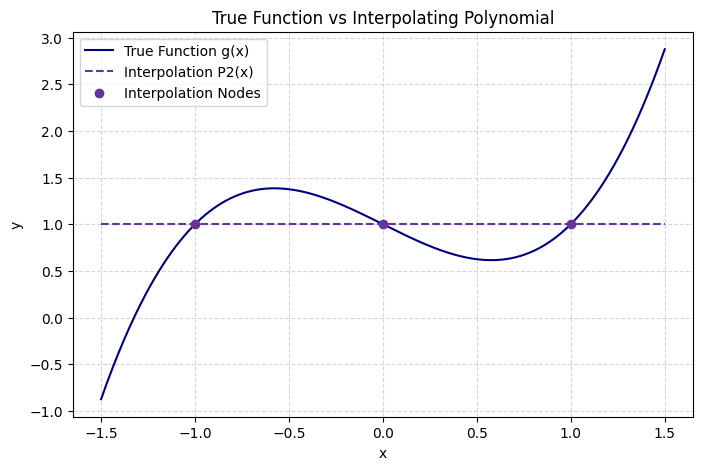

In [ ]:
# Newton's Divided Differences
# g(x) = x^3 - x + 1
# Nodes = {-1, 0, 1}

# Function definition

def g2(x):
    return x**3 - x + 1

# Nodes
x_nodes = np.array([-1, 0, 1], dtype=float)
y_nodes = np.array([g2(x) for x in x_nodes], dtype=float)

# Divided Difference Table
n = len(x_nodes)
dd_table = np.zeros((n, n))
dd_table[:,0] = y_nodes

for j in range(1, n):
    for i in range(n-j):
        dd_table[i][j] = (
            (dd_table[i+1][j-1] - dd_table[i][j-1]) /
            (x_nodes[i+j] - x_nodes[i])
        )

# Display
columns = ['f[x]','1st Diff','2nd Diff']
dd_df = pd.DataFrame(dd_table, columns=columns)

print("Newton Divided Difference Table")
display(dd_df)

# Newton Interpolation Polynomial

def newton_interpolation(x):
    result = dd_table[0,0]

    product_term = 1
    for j in range(1, n):
        product_term *= (x - x_nodes[j-1])
        result += dd_table[0,j] * product_term

    return result

# Evaluate at x = 0.5
x_eval = 0.5
true_value = g2(x_eval)
interpolated_value = newton_interpolation(x_eval)

approximation_error = abs(true_value - interpolated_value)

# results
print("\nEvaluation at x = 0.5")
print("True Value g(0.5):", true_value)
print("Interpolated Value P2(0.5):", interpolated_value)
print("Approximation Error:", approximation_error)

# Plot
x_plot = np.linspace(-1.5, 1.5, 400)
true_curve = [g2(x) for x in x_plot]
interp_curve = [newton_interpolation(x) for x in x_plot]
plt.figure(figsize=(8,5))
plt.plot(x_plot, true_curve, label='True Function g(x)', color='navy')
plt.plot(x_plot, interp_curve, linestyle='--', label='Interpolation P2(x)', color='rebeccapurple')
plt.scatter(x_nodes, y_nodes, label='Interpolation Nodes', color='rebeccapurple', zorder=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Function vs Interpolating Polynomial')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Final Analysis Summary
print("\nSummary:")
print("1. Round-off errors accumulate when rounding intermediate values.")
print("2. Taylor series truncation error decreases as n increases.")
print("3. First-order propagation gives a close approximation to endpoint analysis.")
print("4. Using only three nodes cannot fully reconstruct the cubic function.")


Summary:
1. Round-off errors accumulate when rounding intermediate values.
2. Taylor series truncation error decreases as n increases.
3. First-order propagation gives a close approximation to endpoint analysis.
4. Using only three nodes cannot fully reconstruct the cubic function.


In [ ]:
# Task 6: Interpolation & Polynomial Approximation
#-------------------------------------------------
# 1. Functions Definition
def g1(x):
    """Original function g1(x) = (x + 1)^2"""
    return (x + 1)**2

def g2(x):
    """Original function g2(x) = x^3 - x + 1"""
    return x**3 - x + 1

# 2. Setup Interpolation Nodes
# Case A: g1(x) with 3 nodes (2nd degree polynomial)
x_nodes1 = np.array([-2, -1, 0], dtype=float)
y_nodes1 = g1(x_nodes1)

# Case B: g2(x) with 4 nodes (3rd degree polynomial)
x_nodes2 = np.array([-2, -1, 0, 1], dtype=float)
y_nodes2 = g2(x_nodes2)

# 3. Newton's Divided Differences Implementation
def newton_interpolation(x_nodes, y_nodes, x_input):
    """
    Computes the interpolating polynomial value at x_input
    using Newton's Divided Differences method.
    """
    n = len(x_nodes)
    # Construct Divided Difference Table
    coef = np.zeros([n, n])
    coef[:,0] = y_nodes

    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x_nodes[i+j] - x_nodes[i])

    # Evaluate the polynomial using the diagonal coefficients
    a = coef[0, :]
    n_deg = n - 1
    p = a[n_deg]
    for k in range(1, n_deg + 1):
        p = a[n_deg-k] + (x_input - x_nodes[n_deg-k]) * p
    return p

# 4. Lagrange Interpolation Implementation
def lagrange_interpolation(x_nodes, y_nodes, x_input):
    """
    Computes the interpolating polynomial value at x_input
    using Lagrange Basis Polynomials.
    """
    n = len(x_nodes)
    p = 0
    for i in range(n):
        # Calculate Basis Polynomial L_i(x)
        L_i = 1
        for j in range(n):
            if i != j:
                L_i *= (x_input - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        p += y_nodes[i] * L_i
    return p


test_points = [-1.5, -0.5, 0.5]

print(f"{'x':>10} | {'Method':>15} | {'g1(x) Result':>15} | {'g2(x) Result':>15}")
print("-" * 65)

for x in test_points:
    n1 = newton_interpolation(x_nodes1, y_nodes1, x)
    l1 = lagrange_interpolation(x_nodes1, y_nodes1, x)
    n2 = newton_interpolation(x_nodes2, y_nodes2, x)
    l2 = lagrange_interpolation(x_nodes2, y_nodes2, x)

    print(f"{x:10.2f} | {'Newton':>15} | {n1:15.6f} | {n2:15.6f}")
    print(f"{' ':10} | {'Lagrange':>15} | {l1:15.6f} | {l2:15.6f}")
    print("-" * 65)

         x |          Method |    g1(x) Result |    g2(x) Result
-----------------------------------------------------------------
     -1.50 |          Newton |        0.250000 |       -0.875000
           |        Lagrange |        0.250000 |       -0.875000
-----------------------------------------------------------------
     -0.50 |          Newton |        0.250000 |        1.375000
           |        Lagrange |        0.250000 |        1.375000
-----------------------------------------------------------------
      0.50 |          Newton |        2.250000 |        0.625000
           |        Lagrange |        2.250000 |        0.625000
-----------------------------------------------------------------


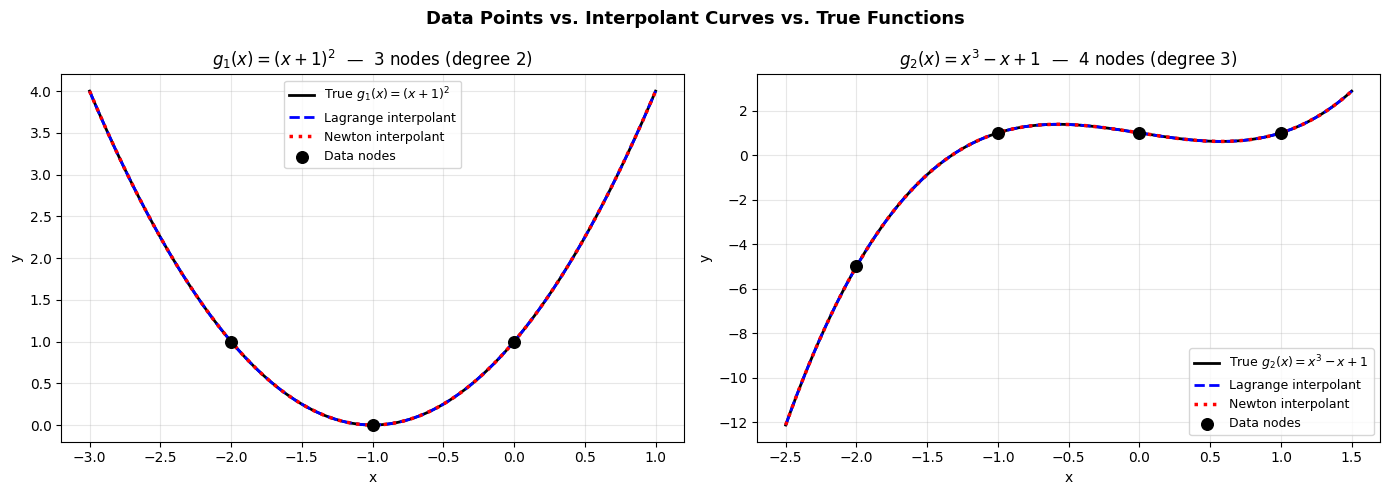

In [ ]:

# Nodes used in Task 3
x_nodes1 = np.array([-2., -1., 0.])          # 3 nodes → degree 2 for g1
y_nodes1 = g1(x_nodes1)

x_nodes2 = np.array([-2., -1., 0., 1.])      # 4 nodes → degree 3 for g2
y_nodes2 = g2(x_nodes2)

# Dense grid for smooth curves
x_fine1 = np.linspace(-3, 1, 400)
x_fine2 = np.linspace(-2.5, 1.5, 400)


y_lag1    = lagrange_interpolation(x_nodes1, y_nodes1, x_fine1)
# Proper Newton eval on full grid:
def newton_eval_grid(x_nodes, y_nodes, x_grid):
    n = len(x_nodes)
    coef = np.zeros((n, n))
    coef[:, 0] = y_nodes
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x_nodes[i+j] - x_nodes[i])
    a = coef[0]   # diagonal of divided diff table
    result = np.zeros_like(x_grid, dtype=float)
    for xi_idx, xi in enumerate(x_grid):
        p = a[n-1]
        for k in range(n-2, -1, -1):
            p = p * (xi - x_nodes[k]) + a[k]
        result[xi_idx] = p
    return result

y_newt1 = newton_eval_grid(x_nodes1, y_nodes1, x_fine1)
y_lag1  = np.array([lagrange_interpolation(x_nodes1, y_nodes1, xi) for xi in x_fine1])

y_newt2 = newton_eval_grid(x_nodes2, y_nodes2, x_fine2)
y_lag2  = np.array([lagrange_interpolation(x_nodes2, y_nodes2, xi) for xi in x_fine2])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- g1(x) = (x+1)^2 ---
ax = axes[0]
ax.plot(x_fine1, g1(x_fine1),  'k-',  lw=2,   label=r'True $g_1(x)=(x+1)^2$')
ax.plot(x_fine1, y_lag1,       'b--', lw=2,   label='Lagrange interpolant')
ax.plot(x_fine1, y_newt1,      'r:',  lw=2.5, label='Newton interpolant')
ax.scatter(x_nodes1, y_nodes1, color='black', zorder=5, s=70, label='Data nodes')
ax.set_title(r'$g_1(x) = (x+1)^2$  —  3 nodes (degree 2)', fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# --- g2(x) = x^3 - x + 1 ---
ax = axes[1]
ax.plot(x_fine2, g2(x_fine2),  'k-',  lw=2,   label=r'True $g_2(x)=x^3-x+1$')
ax.plot(x_fine2, y_lag2,       'b--', lw=2,   label='Lagrange interpolant')
ax.plot(x_fine2, y_newt2,      'r:',  lw=2.5, label='Newton interpolant')
ax.scatter(x_nodes2, y_nodes2, color='black', zorder=5, s=70, label='Data nodes')
ax.set_title(r'$g_2(x) = x^3 - x + 1$  —  4 nodes (degree 3)', fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Data Points vs. Interpolant Curves vs. True Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("  EXISTENCE & UNIQUENESS VERIFICATION")

for label, x_nodes, y_nodes, x_fine, true_fn in [
    ("g1(x) = (x+1)^2",   x_nodes1, y_nodes1, x_fine1, g1),
    ("g2(x) = x^3-x+1",   x_nodes2, y_nodes2, x_fine2, g2),
]:
    y_l = np.array([lagrange_interpolation(x_nodes, y_nodes, xi) for xi in x_fine])
    y_n = newton_eval_grid(x_nodes, y_nodes, x_fine)
    diff = np.max(np.abs(y_l - y_n))

    print(f"\nFunction: {label}")
    print(f"  Number of nodes : {len(x_nodes)}  →  Degree ≤ {len(x_nodes)-1} polynomial")
    print(f"  Max |Lagrange - Newton| = {diff:.2e}")
    if diff < 1e-10:
        print("  ✓  Both methods are NUMERICALLY IDENTICAL.")
    else:
        print("  ✗  Methods differ — check implementation.")


  EXISTENCE & UNIQUENESS VERIFICATION

Function: g1(x) = (x+1)^2
  Number of nodes : 3  →  Degree ≤ 2 polynomial
  Max |Lagrange - Newton| = 4.44e-16
  ✓  Both methods are NUMERICALLY IDENTICAL.

Function: g2(x) = x^3-x+1
  Number of nodes : 4  →  Degree ≤ 3 polynomial
  Max |Lagrange - Newton| = 3.55e-15
  ✓  Both methods are NUMERICALLY IDENTICAL.


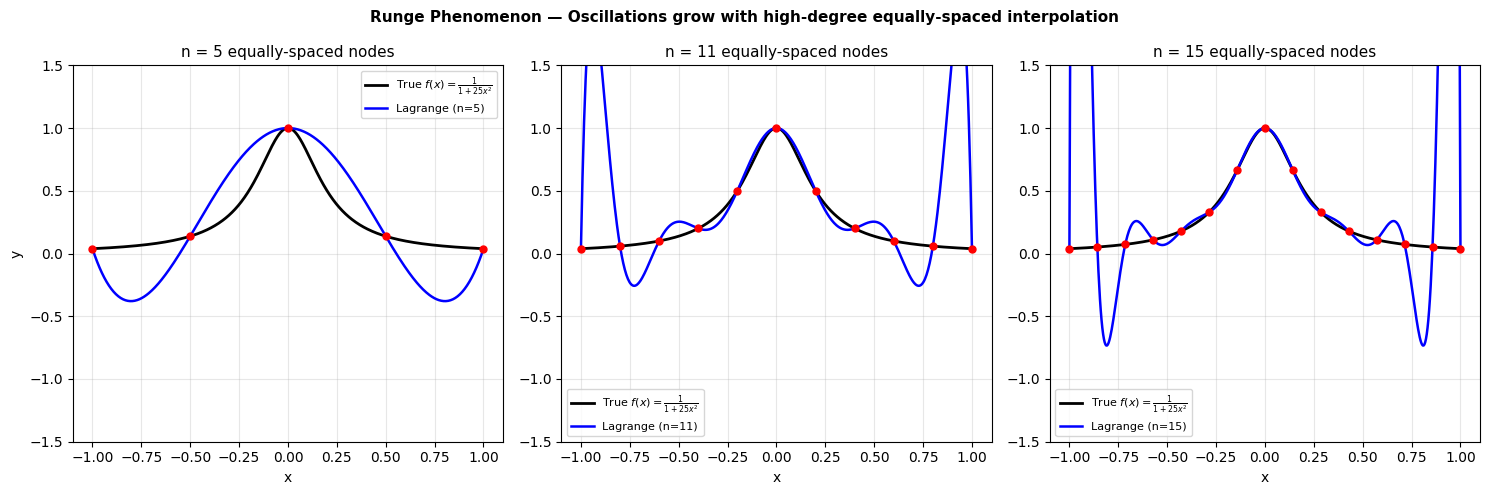

=== Max Interpolation Error vs. Degree (Runge function, equally-spaced) ===
   Nodes | Degree |    Max |Error| | Runge?
------------------------------------------------
       3 |      2 |       0.646218 | YES ⚠
       5 |      4 |       0.438351 | YES ⚠
       7 |      6 |       0.616932 | YES ⚠
       9 |      8 |       1.045166 | YES ⚠
      11 |     10 |       1.915621 | YES ⚠
      13 |     12 |       3.662868 | YES ⚠
      15 |     14 |       7.191540 | YES ⚠

Discussion: Runge Phenomenon 

The Runge phenomenon is the oscillation that appears when using
high-degree polynomials with EQUALLY-SPACED interpolation nodes.

Key points:
  1. For g1(x) = (x+1)^2 (degree 2) and g2(x) = x^3-x+1 (degree 3),
     the interpolating polynomial IS the true function exactly,
     because both functions are already polynomials of degree ≤ n.
     → No Runge phenomenon for low-degree polynomial functions.

  2. For non-polynomial functions (e.g. 1/(1+25x^2)), increasing the
     number of equally-

In [ ]:
# ── Runge Phenomenon: sensitivity to high-order polynomials ──────────────────
# Use the classic Runge function for a clear demonstration
def runge(x):
    return 1 / (1 + 25 * x**2)

x_fine_r = np.linspace(-1, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
node_counts = [5, 11, 15]

for ax, n in zip(axes, node_counts):
    x_nodes_r = np.linspace(-1, 1, n)
    y_nodes_r = runge(x_nodes_r)

    y_lag_r = np.array([lagrange_interpolation(x_nodes_r, y_nodes_r, xi)
                        for xi in x_fine_r])

    ax.plot(x_fine_r, runge(x_fine_r), 'k-',  lw=2,   label=r'True $f(x)=\frac{1}{1+25x^2}$')
    ax.plot(x_fine_r, y_lag_r,         'b-',  lw=1.8, label=f'Lagrange (n={n})')
    ax.scatter(x_nodes_r, y_nodes_r, color='red', zorder=5, s=25)
    ax.set_title(f'n = {n} equally-spaced nodes', fontsize=11)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('y')
fig.suptitle('Runge Phenomenon — Oscillations grow with high-degree equally-spaced interpolation',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Error table ───────────────────────────────────────────────────────────────
print("=== Max Interpolation Error vs. Degree (Runge function, equally-spaced) ===")
print(f"{'Nodes':>8} | {'Degree':>6} | {'Max |Error|':>14} | Runge?")
print("-" * 48)
for n in [3, 5, 7, 9, 11, 13, 15]:
    xn = np.linspace(-1, 1, n)
    yn = runge(xn)
    y_interp = np.array([lagrange_interpolation(xn, yn, xi) for xi in x_fine_r])
    err = np.max(np.abs(y_interp - runge(x_fine_r)))
    flag = "YES ⚠" if err > 0.1 else "No"
    print(f"{n:>8} | {n-1:>6} | {err:>14.6f} | {flag}")

print("""
Discussion: Runge Phenomenon 

The Runge phenomenon is the oscillation that appears when using
high-degree polynomials with EQUALLY-SPACED interpolation nodes.

Key points:
  1. For g1(x) = (x+1)^2 (degree 2) and g2(x) = x^3-x+1 (degree 3),
     the interpolating polynomial IS the true function exactly,
     because both functions are already polynomials of degree ≤ n.
     → No Runge phenomenon for low-degree polynomial functions.

  2. For non-polynomial functions (e.g. 1/(1+25x^2)), increasing the
     number of equally-spaced nodes INCREASES the error near the
     endpoints of the interval — this is the Runge phenomenon.

  3. The phenomenon is NOT a flaw of polynomial interpolation in
     general, but a consequence of equally-spaced nodes at high degree.

Remedies:
  • Chebyshev nodes  → cluster nodes near endpoints, minimises max error.
  • Piecewise / Spline interpolation → always stable, no oscillations.
  • Least-squares fitting → approximation instead of exact interpolation.
""")